In [1]:
import subprocess, sys, os, shutil, threading, time

# ── 1. Delete bitsandbytes completely ─────────────────────────────────
for p in ["/usr/local/lib/python3.12/dist-packages/bitsandbytes"]:
    if os.path.exists(p):
        shutil.rmtree(p, ignore_errors=True)
        print(f"🗑️  Deleted: {p}")
result = subprocess.run(
    ["find", "/usr/local/lib/python3.12/dist-packages",
     "-maxdepth", "1", "-name", "bitsandbytes*"],
    capture_output=True, text=True)
for leftover in result.stdout.strip().split("\n"):
    if leftover and os.path.exists(leftover):
        shutil.rmtree(leftover, ignore_errors=True)
        print(f"🗑️  Deleted leftover: {leftover}")

# ── 2. Install all packages ───────────────────────────────────────────
pkgs = [
    "transformers==4.49.0", "peft==0.14.0", "accelerate==1.3.0",
    "datasets", "pillow", "gradio", "tqdm", "torchvision",
    "rouge-score", "qwen-vl-utils", "einops", "matplotlib",
    "seaborn", "kaggle==2.0.2",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ Packages installed")

# ── 3. Kaggle API setup ───────────────────────────────────────────────
KAGGLE_USERNAME    = "umaimtahir1"
CHECKPOINT_DATASET = f"{KAGGLE_USERNAME}/qwen2vl-checkpoints"

from kaggle_secrets import UserSecretsClient
secrets   = UserSecretsClient()
api_token = secrets.get_secret("KAGGLE_API_TOKEN")

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write(api_token)
os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)
os.environ["KAGGLE_API_TOKEN"] = api_token
print("✅ Kaggle API configured")

# ── 4. Pull existing checkpoints ──────────────────────────────────────
CKPT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"⬇️  Pulling checkpoints from {CHECKPOINT_DATASET}...")
pull = subprocess.run(
    ["kaggle", "datasets", "download",
     "-d", CHECKPOINT_DATASET,
     "-p", CKPT_DIR, "--unzip"],
    capture_output=True, text=True)
if pull.returncode == 0:
    print("✅ Checkpoints restored!")
    for f in os.listdir(CKPT_DIR):
        print(f"   📁 {f}")
else:
    print(f"⚠️  No checkpoints yet — fresh start")

# ── 5. Create output dirs ─────────────────────────────────────────────
for d in ["/kaggle/working/outputs",
          "/kaggle/working/qwen2vl_adapter",
          CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── 6. Anti-idle (prints every 5 min to keep session alive) ──────────
def anti_idle():
    c = 0
    while True:
        time.sleep(290)
        c += 1
        print(f"  ⏳ keepalive #{c}", flush=True)
threading.Thread(target=anti_idle, daemon=True).start()
print("✅ Anti-idle running")

print("\n" + "="*55)
print("  ⚠️  NOW: Runtime → Restart Session → Run All")
print("="*55)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 57.8 MB/s eta 0:00:00
✅ Packages installed
✅ Kaggle API configured
⬇️  Pulling checkpoints from umaimtahir1/qwen2vl-checkpoints...
✅ Checkpoints restored!
   📁 readme.txt
   📁 adapter_epoch2
   📁 adapter_epoch1
   📁 adapter_latest
   📁 train_state.json
   📁 adapter_best
✅ Anti-idle running

  ⚠️  NOW: Ru

In [2]:
import torch, sys, os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("="*65)
print("              GPU ENVIRONMENT")
print("="*65)
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA     : {torch.version.cuda}")
print(f"  GPUs     : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}  : {p.name}  {p.total_memory/1e9:.1f}GB")

assert torch.cuda.is_available(), "❌ No GPU!"
DEVICE = "cuda"
print("\n✅ GPU ready")

              GPU ENVIRONMENT
  PyTorch  : 2.10.0+cu128
  CUDA     : 12.8
  GPUs     : 2
  GPU 0  : Tesla T4  15.6GB
  GPU 1  : Tesla T4  15.6GB

✅ GPU ready


In [3]:
import os

KAGGLE_USERNAME    = "umaimtahir1"
CHECKPOINT_DATASET = f"{KAGGLE_USERNAME}/qwen2vl-checkpoints"

# ── Paths ─────────────────────────────────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example"
OUTPUT_DIR   = "/kaggle/working/outputs"
ADAPTER_DIR  = "/kaggle/working/qwen2vl_adapter"
CKPT_DIR     = "/kaggle/working/checkpoints"
for d in [OUTPUT_DIR, ADAPTER_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Model ─────────────────────────────────────────────────────────────
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

# ── Image ─────────────────────────────────────────────────────────────
IMAGE_SIZE    = 512
IMAGE_EXTS    = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp'}
MARKDOWN_EXTS = {'.mmd', '.md', '.txt'}

# ── Training — tuned for T4×2 100% utilization ────────────────────────
BATCH_SIZE     = 2        # 2 per step × 2 GPUs = effective 4 per step
GRAD_ACCUM     = 4        # effective batch = 8
NUM_EPOCHS     = 3
LEARNING_RATE  = 2e-4
WARMUP_RATIO   = 0.05
MAX_SEQ_LEN    = 768
TRAIN_RATIO    = 0.80
SEED           = 42
NUM_WORKERS    = 4
SAVE_EVERY     = 50       # local save every 50 steps
PUSH_EVERY     = 200      # push to Kaggle dataset every 200 steps

# ── LoRA ──────────────────────────────────────────────────────────────
LORA_RANK    = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj","k_proj","v_proj","o_proj",
                "gate_proj","up_proj","down_proj"]

# ── Generation ────────────────────────────────────────────────────────
MAX_NEW_TOKENS = 512
INSTRUCTION = (
    "You are an expert document understanding assistant. "
    "Analyze this document image and convert it into well-structured "
    "Markdown. Preserve all headings, paragraphs, lists, tables, "
    "equations, and code blocks using proper Markdown syntax."
)

print("✅ Config loaded")
print(f"   Model         : {MODEL_ID}")
print(f"   Batch         : {BATCH_SIZE} × accum {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}")
print(f"   Epochs        : {NUM_EPOCHS}")
print(f"   LoRA rank     : {LORA_RANK}")
print(f"   Workers       : {NUM_WORKERS}")

✅ Config loaded
   Model         : Qwen/Qwen2-VL-2B-Instruct
   Batch         : 2 × accum 4 = 8
   Epochs        : 3
   LoRA rank     : 16
   Workers       : 4


In [4]:
import os
from pathlib import Path
from collections import defaultdict
from PIL import Image

print("="*65)
print("            DATASET EXPLORATION")
print("="*65)

image_files    = []
markdown_files = []
ext_count      = defaultdict(int)

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    if level <= 2:
        print(f"{'  '*level}📁 {os.path.basename(root)}/  [{len(files)} files]")
    for fname in files:
        ext  = Path(fname).suffix.lower()
        full = os.path.join(root, fname)
        ext_count[ext] += 1
        if ext in IMAGE_EXTS:
            image_files.append(full)
        elif ext in MARKDOWN_EXTS:
            markdown_files.append(full)

print(f"\n  Image files    : {len(image_files)}")
print(f"  Markdown files : {len(markdown_files)}")
print(f"\n  Extensions:")
for ext, cnt in sorted(ext_count.items(), key=lambda x: -x[1]):
    print(f"    {ext:10s} → {cnt}")

            DATASET EXPLORATION
📁 nougat-training-dataset-example/  [1 files]
  📁 0508/  [0 files]
    📁 astro-ph0508131/  [5 files]
    📁 astro-ph0508089/  [15 files]
    📁 math0508650/  [11 files]
    📁 math-ph0508001/  [11 files]
    📁 gr-qc0508101/  [15 files]
    📁 nucl-th0508040/  [19 files]
    📁 hep-th0508021/  [17 files]
    📁 astro-ph0508602/  [5 files]
    📁 hep-ex0508014/  [9 files]
    📁 math0508511/  [15 files]
    📁 nucl-ex0508014/  [21 files]
    📁 cond-mat0508115/  [9 files]
    📁 math0508205/  [15 files]
    📁 math0508258/  [9 files]
    📁 cond-mat0508204/  [27 files]
    📁 astro-ph0508280/  [17 files]
    📁 astro-ph0508340/  [7 files]
    📁 cond-mat0508610/  [9 files]
    📁 math0508140/  [9 files]
    📁 cond-mat0508518/  [9 files]
    📁 cs0508092/  [5 files]
    📁 astro-ph0508338/  [5 files]
    📁 hep-th0508136/  [7 files]
    📁 math0508308/  [11 files]
    📁 astro-ph0508069/  [17 files]
    📁 astro-ph0508252/  [7 files]
    📁 nucl-th0508033/  [11 files]
    📁 astro-

In [5]:
from pathlib import Path

def find_markdown(img_path, md_set):
    stem   = Path(img_path).stem
    parent = str(Path(img_path).parent)
    for ext in ['.mmd', '.md', '.txt']:
        c = os.path.join(parent, stem + ext)
        if c in md_set:
            return c
    return None

md_set    = set(markdown_files)
ALL_PAIRS = []
for img in image_files:
    mp = find_markdown(img, md_set)
    if mp:
        ALL_PAIRS.append({"image_path": img, "markdown_path": mp})

print(f"✅ Valid pairs: {len(ALL_PAIRS)}")

for i, pair in enumerate(ALL_PAIRS[:3]):
    img = Image.open(pair['image_path'])
    with open(pair['markdown_path'], 'r', encoding='utf-8', errors='replace') as f:
        mdc = f.read()
    print(f"\n  Sample {i+1}:")
    print(f"    Image size : {img.size}  mode: {img.mode}")
    print(f"    MD length  : {len(mdc)} chars")
    print(f"    Preview    : {mdc[:120].strip()}")

assert len(ALL_PAIRS) > 0, "❌ No pairs found! Check dataset path."

✅ Valid pairs: 14236

  Sample 1:
    Image size : (816, 1056)  mode: RGB
    MD length  : 1851 chars
    Preview    : ## 3 Analysis and Results

In order to study the gas velocity field, we apply the tilted-ring decomposition combined w

  Sample 2:
    Image size : (816, 1056)  mode: RGB
    MD length  : 1612 chars
    Preview    : approximate the stellar velocity field with an exponential thin disk to emphasize the kinematic signatures of the centra

  Sample 3:
    Image size : (816, 1056)  mode: RGB
    MD length  : 3460 chars
    Preview    : leads to the closed expression for the total bolometric flux from these objects:

\[F_{\rm bol}=\frac{3}{8\pi}\frac{c^{5


/tmp/ipykernel_57/3712769502.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


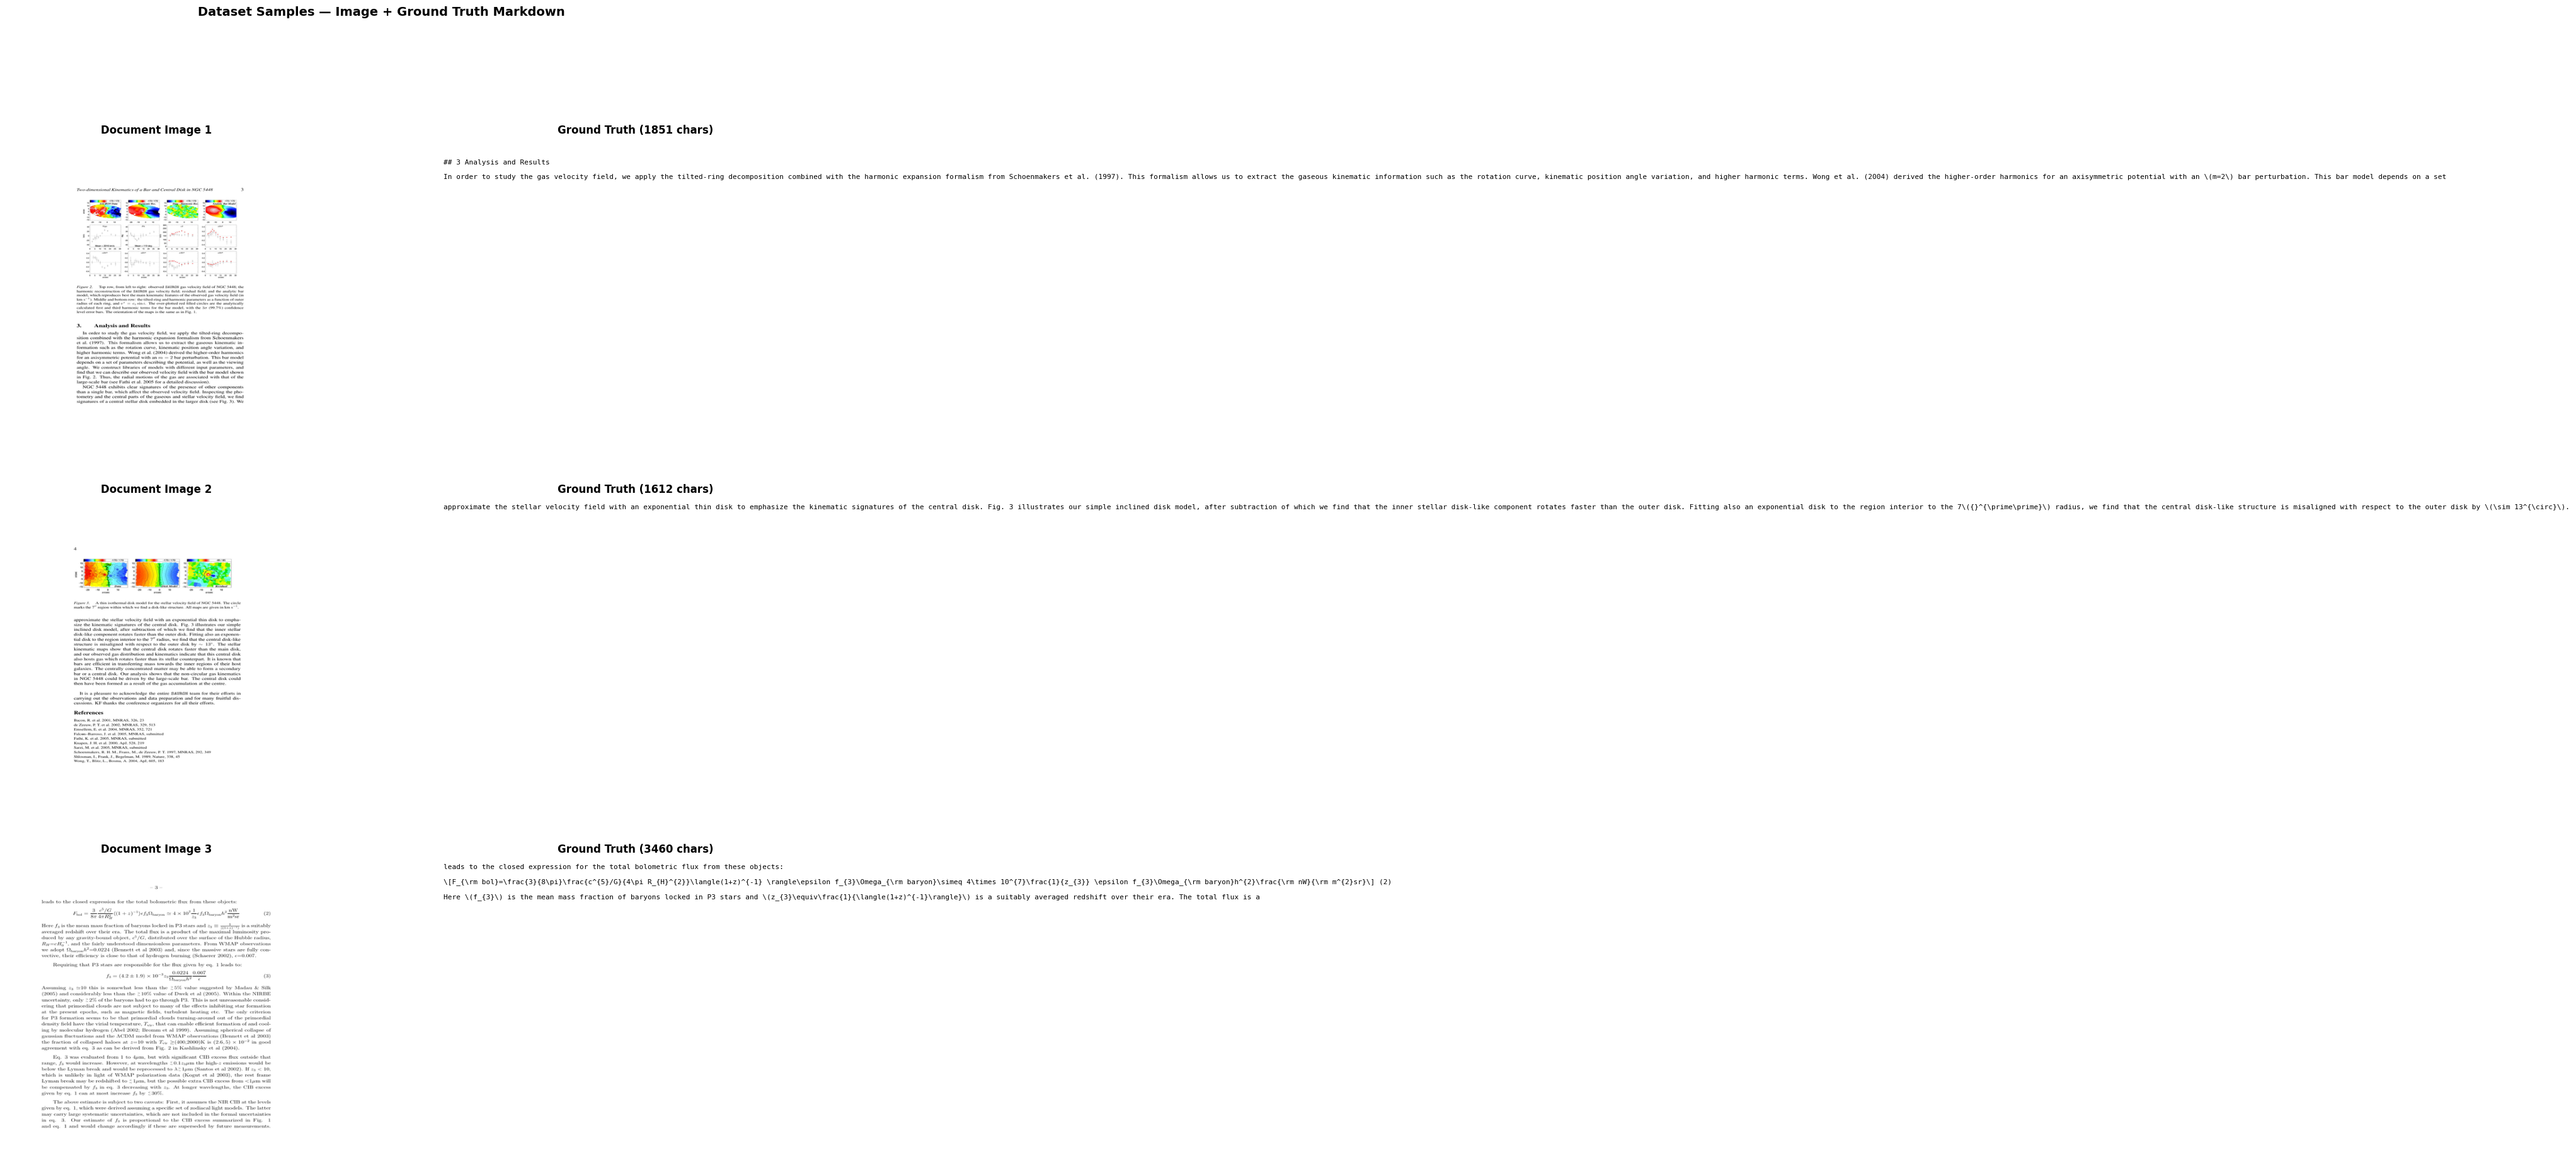

✅ Saved → /kaggle/working/outputs/dataset_samples.png


In [6]:
import matplotlib.pyplot as plt

def visualize_samples(pairs, n=3):
    n   = min(n, len(pairs))
    fig, axes = plt.subplots(n, 2, figsize=(18, 7*n))
    if n == 1: axes = [axes]
    fig.suptitle("Dataset Samples — Image + Ground Truth Markdown",
                 fontsize=14, fontweight='bold')
    for i, pair in enumerate(pairs[:n]):
        img = Image.open(pair['image_path']).convert("RGB")
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
        with open(pair['markdown_path'], 'r',
                  encoding='utf-8', errors='replace') as f:
            mdc = f.read()
        axes[i][0].imshow(img)
        axes[i][0].set_title(f"Document Image {i+1}", fontweight='bold')
        axes[i][0].axis('off')
        axes[i][1].set_facecolor('#f8f9fa')
        axes[i][1].text(0.02, 0.98, mdc[:500],
                        transform=axes[i][1].transAxes,
                        fontsize=8, va='top', fontfamily='monospace')
        axes[i][1].set_title(f"Ground Truth ({len(mdc)} chars)",
                             fontweight='bold')
        axes[i][1].axis('off')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/dataset_samples.png",
                dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {OUTPUT_DIR}/dataset_samples.png")

visualize_samples(ALL_PAIRS)

In [7]:
import random

random.seed(SEED)
shuffled    = ALL_PAIRS.copy()
random.shuffle(shuffled)
n_train     = int(len(shuffled) * TRAIN_RATIO)
TRAIN_PAIRS = shuffled[:n_train]
VAL_PAIRS   = shuffled[n_train:]

print(f"✅ Total  : {len(shuffled)}")
print(f"   Train  : {len(TRAIN_PAIRS)}  ({TRAIN_RATIO*100:.0f}%)")
print(f"   Val    : {len(VAL_PAIRS)}  ({(1-TRAIN_RATIO)*100:.0f}%)")

✅ Total  : 14236
   Train  : 11388  (80%)
   Val    : 2848  (20%)


In [8]:
import torch
from torch.utils.data import Dataset
from PIL import Image, UnidentifiedImageError

class NougatChatMLDataset(Dataset):
    def __init__(self, pairs, processor, instruction,
                 max_length=MAX_SEQ_LEN, image_size=IMAGE_SIZE):
        self.processor   = processor
        self.instruction = instruction
        self.max_length  = max_length
        self.image_size  = image_size

        print("🔍 Validating images...")
        self.pairs = []
        skipped    = 0
        for pair in pairs:
            if self._is_valid(pair['image_path']):
                self.pairs.append(pair)
            else:
                skipped += 1
        print(f"✅ Valid: {len(self.pairs)}  |  Skipped corrupt: {skipped}")

    def _is_valid(self, path):
        try:
            with Image.open(path) as img:
                img.verify()
            return True
        except Exception:
            return False

    def _load_image(self, path):
        try:
            img = Image.open(path).convert("RGB")
            return img.resize((self.image_size, self.image_size),
                              Image.LANCZOS)
        except Exception:
            return Image.new("RGB",
                             (self.image_size, self.image_size),
                             (255, 255, 255))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair  = self.pairs[idx]
        image = self._load_image(pair['image_path'])

        with open(pair['markdown_path'], 'r',
                  encoding='utf-8', errors='replace') as f:
            md_text = f.read().strip()

        messages = [
            {"role": "user", "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": self.instruction}
            ]},
            {"role": "assistant", "content": md_text}
        ]

        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False)

        inputs = self.processor(
            text=[text], images=[image],
            return_tensors="pt", padding=False,
            truncation=True, max_length=self.max_length,
        )

        input_ids = inputs["input_ids"].squeeze(0)
        labels    = input_ids.clone()

        marker     = "<|im_start|>assistant"
        marker_ids = self.processor.tokenizer.encode(
            marker, add_special_tokens=False)
        seq_len = len(input_ids)
        masked  = False
        for i in range(seq_len - len(marker_ids), -1, -1):
            if input_ids[i:i+len(marker_ids)].tolist() == marker_ids:
                labels[:i+len(marker_ids)] = -100
                masked = True
                break
        if not masked:
            labels[:int(seq_len * 0.6)] = -100

        result = {
            "input_ids":      input_ids,
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels":         labels,
        }
        if "pixel_values"   in inputs:
            result["pixel_values"]   = inputs["pixel_values"]
        if "image_grid_thw" in inputs:
            result["image_grid_thw"] = inputs["image_grid_thw"]
        return result

print("✅ Dataset class ready")

✅ Dataset class ready


In [9]:
from torch.utils.data import DataLoader
from transformers import AutoProcessor
import torch

# ── Patch PEFT before importing it ───────────────────────────────────
import peft.import_utils as peft_utils
peft_utils.is_bnb_available      = lambda: False
peft_utils.is_bnb_4bit_available = lambda: False

# ── Load processor ────────────────────────────────────────────────────
processor = AutoProcessor.from_pretrained(
    MODEL_ID, trust_remote_code=True,
    min_pixels=256*256, max_pixels=IMAGE_SIZE*IMAGE_SIZE,
)
print("✅ Processor loaded")

# ── Collator ──────────────────────────────────────────────────────────
def chatml_collate_fn(batch):
    pad_id  = processor.tokenizer.pad_token_id or 0
    max_len = max(item["input_ids"].shape[0] for item in batch)
    ids, masks, labs, pixels, grids = [], [], [], [], []

    for item in batch:
        seq = item["input_ids"].shape[0]
        pad = max_len - seq
        ids.append(torch.cat([
            item["input_ids"],
            torch.full((pad,), pad_id, dtype=torch.long)]))
        masks.append(torch.cat([
            item["attention_mask"],
            torch.zeros(pad, dtype=torch.long)]))
        labs.append(torch.cat([
            item["labels"],
            torch.full((pad,), -100, dtype=torch.long)]))
        if "pixel_values"   in item: pixels.append(item["pixel_values"])
        if "image_grid_thw" in item: grids.append(item["image_grid_thw"])

    result = {
        "input_ids":      torch.stack(ids),
        "attention_mask": torch.stack(masks),
        "labels":         torch.stack(labs),
    }
    if pixels:
        try:    result["pixel_values"] = torch.cat(pixels, dim=0)
        except: result["pixel_values"] = pixels[0]
    if grids:
        try:    result["image_grid_thw"] = torch.cat(grids, dim=0)
        except: result["image_grid_thw"] = grids[0]
    return result

# ── Build datasets ────────────────────────────────────────────────────
train_dataset = NougatChatMLDataset(TRAIN_PAIRS, processor, INSTRUCTION)
val_dataset   = NougatChatMLDataset(VAL_PAIRS,   processor, INSTRUCTION)

# ── DataLoaders — pin_memory + prefetch = GPU never waits for CPU ─────
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=chatml_collate_fn,
    num_workers=NUM_WORKERS, pin_memory=True,
    prefetch_factor=2, persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=chatml_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True,
)
print(f"✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

2026-05-06 10:36:33.545422: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778063793.751623      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778063793.819301      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778063794.299683      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778063794.299728      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778063794.299730      57 computation_placer.cc:177] computation placer alr

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

✅ Processor loaded
🔍 Validating images...
✅ Valid: 11366  |  Skipped corrupt: 22
🔍 Validating images...
✅ Valid: 2841  |  Skipped corrupt: 7
✅ Train batches: 5683 | Val batches: 1421


In [10]:
from transformers import Qwen2VLForConditionalGeneration
from peft import LoraConfig, get_peft_model, TaskType
import torch

torch.autograd.graph.set_warn_on_accumulate_grad_stream_mismatch(False)

print(f"⚙️  Loading {MODEL_ID} in fp16...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True,
)
print(f"✅ Model loaded | {next(model.parameters()).device}")

for i in range(torch.cuda.device_count()):
    used  = torch.cuda.memory_allocated(i)/1e9
    total = torch.cuda.get_device_properties(i).total_memory/1e9
    print(f"   GPU {i}: {used:.1f}GB used / {total:.1f}GB total")

model.gradient_checkpointing_enable()
model.enable_input_require_grads()

lora_config = LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGETS,
    lora_dropout=LORA_DROPOUT,
    bias="none", task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
print("\n" + "="*65)
model.print_trainable_parameters()
print("="*65)
print("✅ fp16 + LoRA ready")

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


⚙️  Loading Qwen/Qwen2-VL-2B-Instruct in fp16...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

✅ Model loaded | cuda:0
   GPU 0: 2.5GB used / 15.6GB total
   GPU 1: 2.0GB used / 15.6GB total

trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290
✅ fp16 + LoRA ready


In [12]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from torch.amp import GradScaler, autocast
from tqdm.auto import tqdm
import time, json, os, torch, subprocess, shutil

CKPT_STATE_FILE = f"{CKPT_DIR}/train_state.json"

# ── Checkpoint helpers ────────────────────────────────────────────────
def load_state():
    if os.path.exists(CKPT_STATE_FILE):
        s = json.load(open(CKPT_STATE_FILE))
        print(f"♻️  Resuming from epoch {s['epoch']}, step {s['global_step']}")
        print(f"   Val losses so far : {s['val_losses']}")
        print(f"   Best val loss     : {s['best_val_loss']:.4f}")
        return s
    print("🆕 No checkpoint — starting fresh")
    return {"global_step": 0, "epoch": 0,
            "best_val_loss": float('inf'),
            "train_losses": [], "val_losses": []}

def save_state(s):
    json.dump(s, open(CKPT_STATE_FILE, "w"))

def push_to_kaggle(tag="latest"):
    try:
        meta = {
            "title": "qwen2vl-checkpoints",
            "id":    CHECKPOINT_DATASET,
            "licenses": [{"name": "CC0-1.0"}]
        }
        with open(f"{CKPT_DIR}/dataset-metadata.json", "w") as f:
            json.dump(meta, f)
        r = subprocess.run(
            ["kaggle", "datasets", "version",
             "-p", CKPT_DIR,
             "-m", f"ckpt_{tag}",
             "--dir-mode", "zip"],
            capture_output=True, text=True, timeout=300)
        if r.returncode == 0:
            print(f"  ☁️  Pushed to Kaggle ✅ ({tag})")
        else:
            print(f"  ⚠️  Push failed: {r.stderr[:150]}")
    except Exception as e:
        print(f"  ⚠️  Push error (training continues): {e}")

def save_ckpt(model, processor, opt, sched, scaler, s, tag, push=False):
    path = f"{CKPT_DIR}/adapter_{tag}"
    os.makedirs(path, exist_ok=True)
    model.save_pretrained(path)
    processor.save_pretrained(path)
    torch.save({
        "opt":    opt.state_dict(),
        "sched":  sched.state_dict(),
        "scaler": scaler.state_dict(),
    }, f"{path}/optim.pt")
    save_state(s)
    print(f"  💾 Saved locally → {path}")
    if push:
        push_to_kaggle(tag)

def evaluate(model, loader, max_b=15):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_b: break
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            with autocast("cuda"):
                out = model(**batch)
            if out.loss is not None:
                total += out.loss.item(); n += 1
    model.train()
    return total / max(n, 1)

# ── Load state ────────────────────────────────────────────────────────
state = load_state()

total_steps  = (len(train_loader) // GRAD_ACCUM) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=0.01, eps=1e-8)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps)
scaler = GradScaler("cuda")

# ── Restore optimizer if resuming ────────────────────────────────────
opt_path = f"{CKPT_DIR}/adapter_latest/optim.pt"
if os.path.exists(opt_path):
    saved = torch.load(opt_path, map_location="cpu", weights_only=True)
    optimizer.load_state_dict(saved["opt"])
    scheduler.load_state_dict(saved["sched"])
    scaler.load_state_dict(saved["scaler"])
    print("♻️  Optimizer/scheduler/scaler restored")

print("="*65)
print(f"  Resuming at epoch  : {state['epoch']+1} / {NUM_EPOCHS}")
print(f"  Global step        : {state['global_step']} / {total_steps}")
print(f"  Remaining epochs   : {NUM_EPOCHS - state['epoch']}")
print(f"  Best val so far    : {state['best_val_loss']:.4f}")
print(f"  Mixed precision    : fp16 autocast (tensor cores ON)")
print(f"  Effective batch    : {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}")
print("="*65)

if state["epoch"] >= NUM_EPOCHS:
    print("✅ Training already complete! Run inference cells.")
else:
    model.train()
    for epoch in range(state["epoch"], NUM_EPOCHS):
        epoch_loss, n_batches, accum_loss = 0.0, 0, 0.0
        t0   = time.time()
        pbar = tqdm(train_loader,
                    desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=True)
        optimizer.zero_grad()

        for step, batch in enumerate(pbar):
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}

            with autocast("cuda"):
                out  = model(**batch)
                loss = out.loss / GRAD_ACCUM

            scaler.scale(loss).backward()
            accum_loss += loss.item()

            if (step + 1) % GRAD_ACCUM == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

                epoch_loss           += accum_loss
                n_batches            += 1
                state["global_step"] += 1
                state["train_losses"].append(accum_loss)

                g0 = torch.cuda.memory_allocated(0)/1e9
                g1 = torch.cuda.memory_allocated(1)/1e9 \
                     if torch.cuda.device_count() > 1 else 0
                pbar.set_postfix({
                    "loss": f"{accum_loss:.4f}",
                    "lr":   f"{scheduler.get_last_lr()[0]:.2e}",
                    "G0":   f"{g0:.1f}GB",
                    "G1":   f"{g1:.1f}GB",
                })

                # Local save every 50 steps
                if state["global_step"] % SAVE_EVERY == 0:
                    save_ckpt(model, processor, optimizer,
                              scheduler, scaler, state,
                              "latest", push=False)

                # Push to Kaggle every 200 steps
                if state["global_step"] % PUSH_EVERY == 0:
                    save_ckpt(model, processor, optimizer,
                              scheduler, scaler, state,
                              "latest", push=True)

                accum_loss = 0.0

        # ── End of epoch ──────────────────────────────────────────────
        val_loss       = evaluate(model, val_loader)
        avg_train      = epoch_loss / max(n_batches, 1)
        state["epoch"] = epoch + 1
        state["val_losses"].append(val_loss)

        print(f"\n  Epoch {epoch+1} | train: {avg_train:.4f} | "
              f"val: {val_loss:.4f} | "
              f"{(time.time()-t0)/60:.1f}min")

        # Always push at end of epoch
        save_ckpt(model, processor, optimizer, scheduler, scaler,
                  state, f"epoch{epoch+1}", push=True)

        if val_loss < state["best_val_loss"]:
            state["best_val_loss"] = val_loss
            save_ckpt(model, processor, optimizer, scheduler, scaler,
                      state, "best", push=True)
            print(f"  🏆 Best val loss: {val_loss:.4f}")

        model.train()

    print(f"\n✅ Training done! Best val loss: {state['best_val_loss']:.4f}")
    push_to_kaggle("final")

♻️  Resuming from epoch 2, step 4950
   Val losses so far : [0.3748011608918508, 0.37258114417394]
   Best val loss     : 0.3726
♻️  Optimizer/scheduler/scaler restored
  Resuming at epoch  : 3 / 3
  Global step        : 4950 / 4260
  Remaining epochs   : 1
  Best val so far    : 0.3726
  Mixed precision    : fp16 autocast (tensor cores ON)
  Effective batch    : 2 × 4 = 8


RuntimeError: DataLoader worker (pid(s) 677, 678, 679, 680) exited unexpectedly

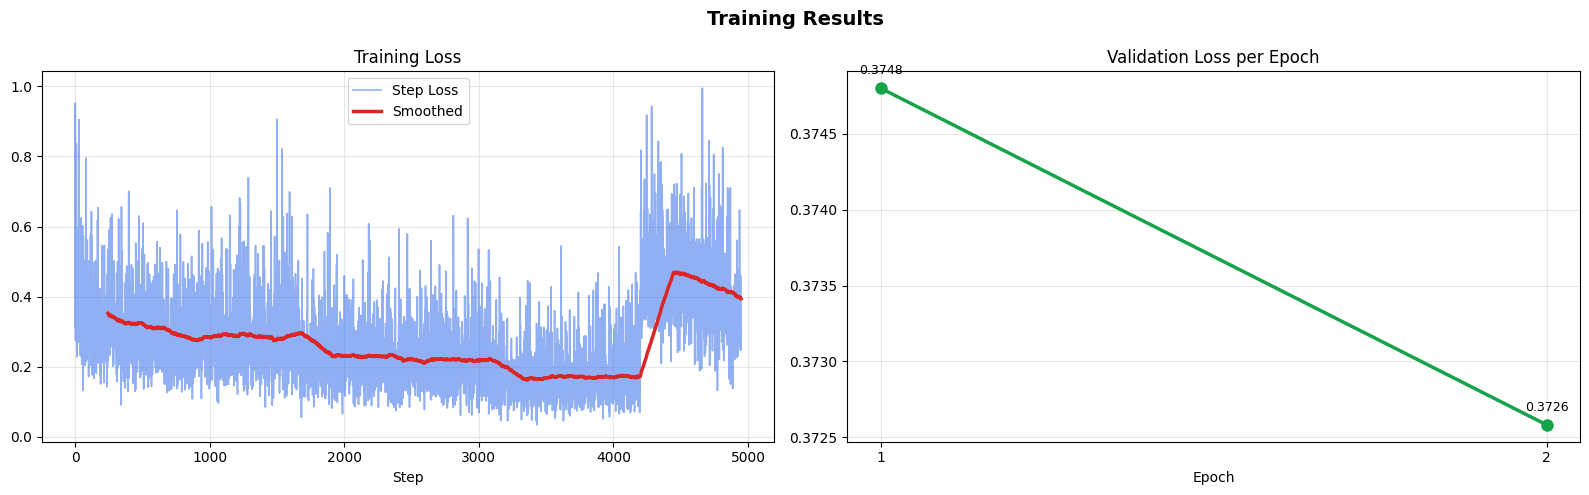

✅ Saved → /kaggle/working/outputs/loss_curves.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Training Results", fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(state["train_losses"], color='#2563eb',
         lw=1.2, alpha=0.5, label='Step Loss')
if len(state["train_losses"]) > 10:
    w  = max(5, len(state["train_losses"])//20)
    sm = np.convolve(state["train_losses"],
                     np.ones(w)/w, mode='valid')
    ax1.plot(range(w-1, len(state["train_losses"])), sm,
             color='#dc2626', lw=2.5, label='Smoothed')
ax1.set_title("Training Loss"); ax1.set_xlabel("Step")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
eps = list(range(1, len(state["val_losses"])+1))
ax2.plot(eps, state["val_losses"], 'o-',
         color='#16a34a', lw=2.5, markersize=8)
for x, y in zip(eps, state["val_losses"]):
    ax2.annotate(f'{y:.4f}', (x, y),
                 textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9)
ax2.set_title("Validation Loss per Epoch")
ax2.set_xlabel("Epoch"); ax2.set_xticks(eps)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {OUTPUT_DIR}/loss_curves.png")

In [14]:
from peft import PeftModel
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
import torch

import peft.import_utils as pu
pu.is_bnb_available      = lambda: False
pu.is_bnb_4bit_available = lambda: False

BEST_CKPT = f"{CKPT_DIR}/adapter_best"
print(f"⚙️  Loading best adapter from {BEST_CKPT}...")

base = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, device_map="auto",
    torch_dtype=torch.float16, trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, BEST_CKPT)
ft_model.eval()

ft_processor = AutoProcessor.from_pretrained(
    BEST_CKPT, trust_remote_code=True,
    min_pixels=256*256, max_pixels=IMAGE_SIZE*IMAGE_SIZE,
)
print("✅ Fine-tuned model loaded")

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


⚙️  Loading best adapter from /kaggle/working/checkpoints/adapter_best...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Fine-tuned model loaded


In [15]:
from PIL import Image
from torch.amp import autocast

def generate_markdown(model, proc, image_or_path,
                      instruction=INSTRUCTION,
                      max_new_tokens=MAX_NEW_TOKENS):
    if isinstance(image_or_path, str):
        image = Image.open(image_or_path).convert("RGB")
    else:
        image = image_or_path.convert("RGB")
    image = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)

    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": instruction}
    ]}]
    text   = proc.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    inputs = proc(text=[text], images=[image],
                  return_tensors="pt", padding=True)
    inputs = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
              for k, v in inputs.items()}

    with torch.no_grad(), autocast("cuda"):
        ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=proc.tokenizer.eos_token_id,
        )
    new = ids[:, inputs["input_ids"].shape[1]:]
    return proc.tokenizer.batch_decode(
        new, skip_special_tokens=True)[0].strip()

print("✅ generate_markdown() ready")

✅ generate_markdown() ready


Generating for 10 validation samples...


  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


  ⏳ keepalive #31
  ⏳ keepalive #32


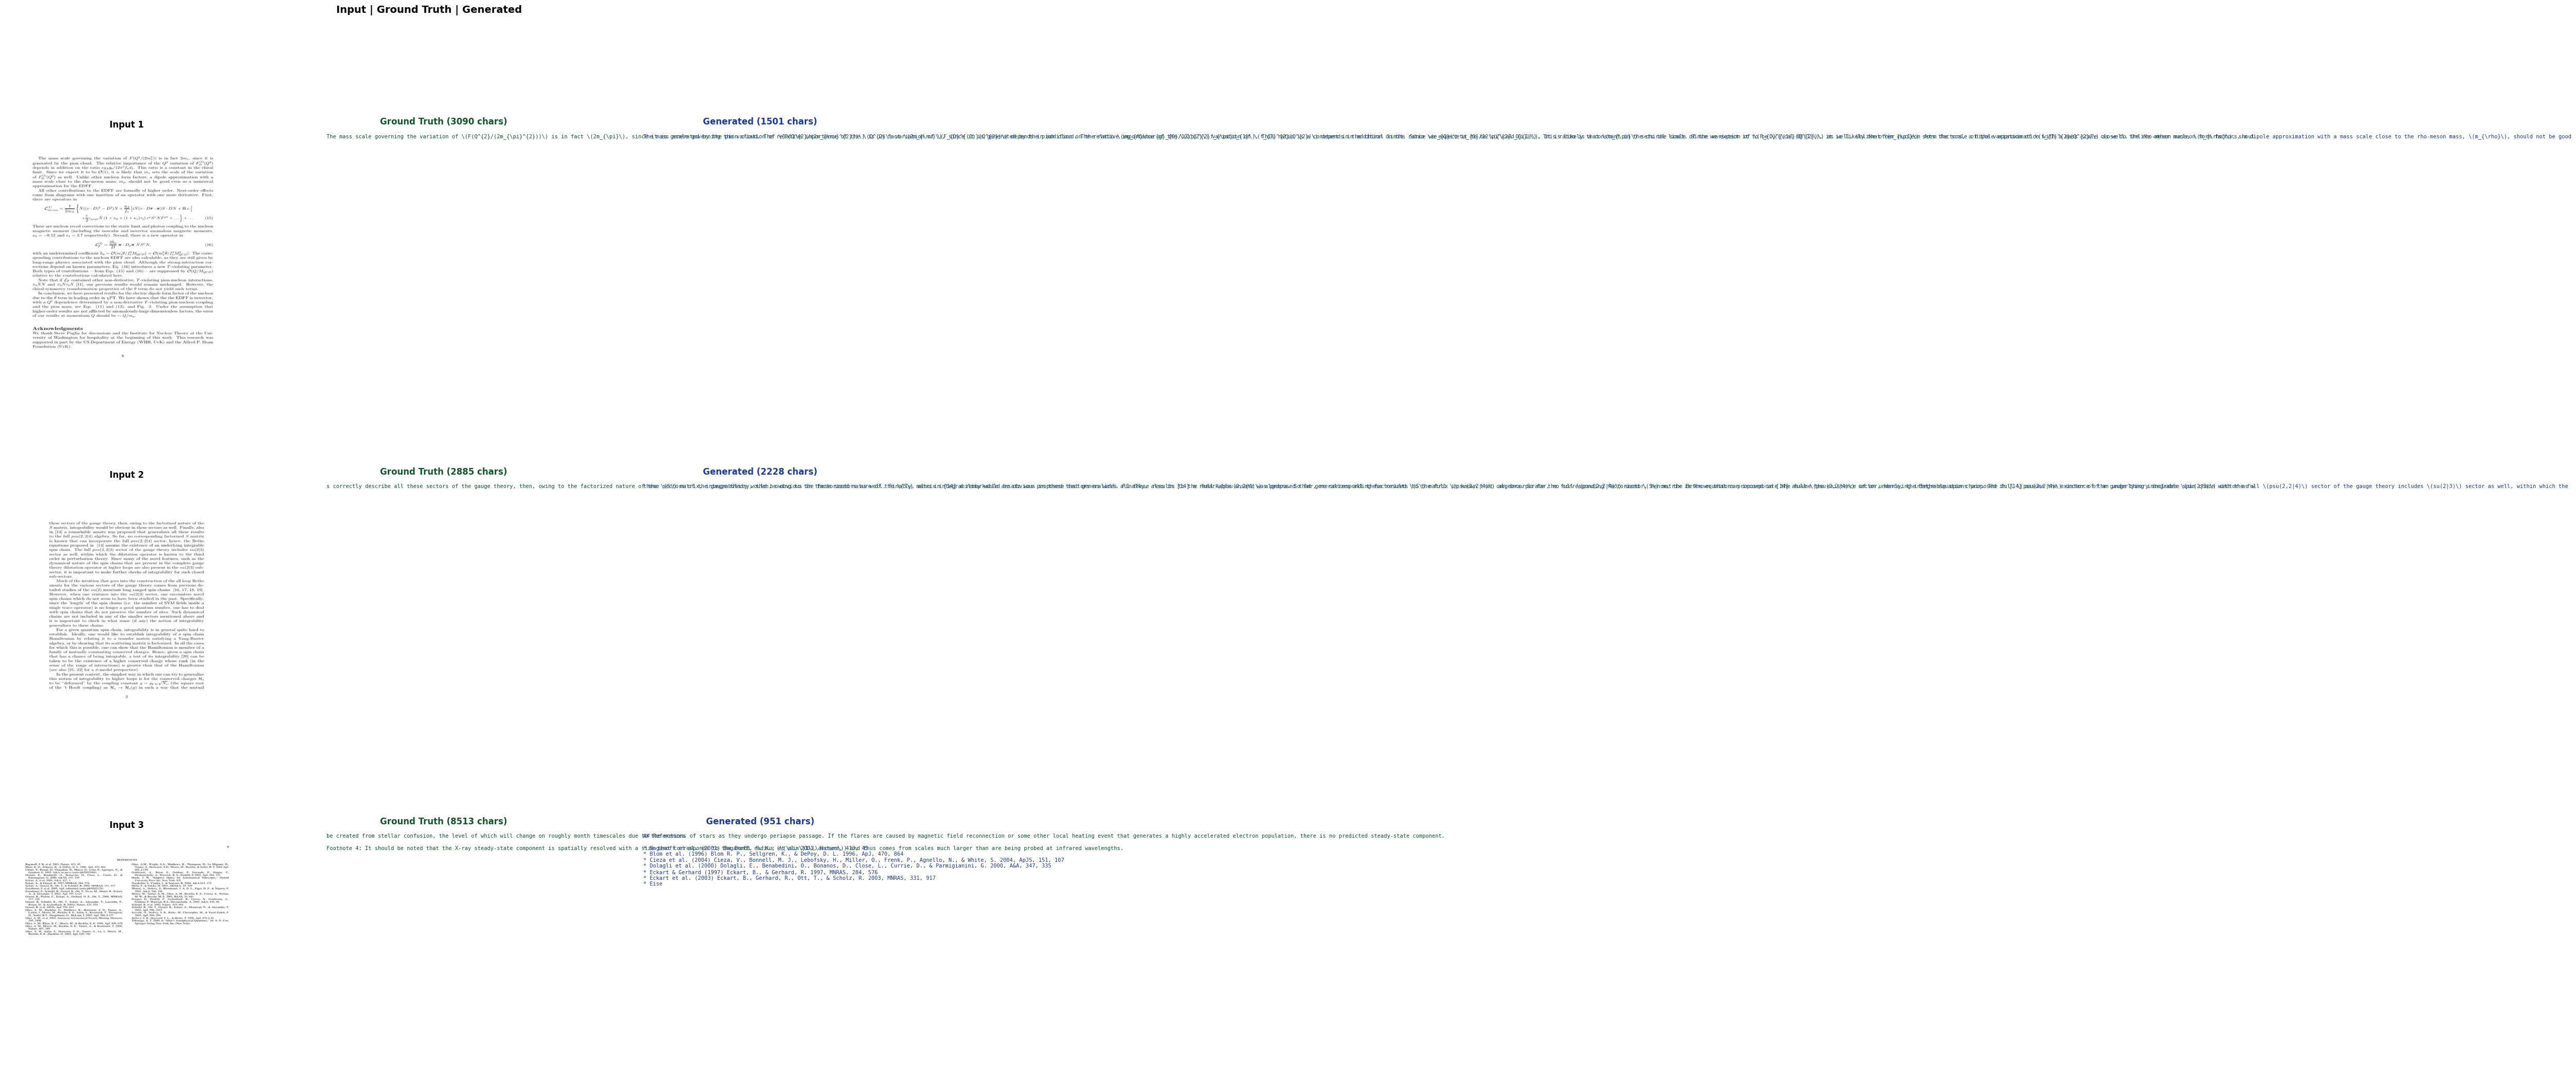

✅ Saved → /kaggle/working/outputs/predictions.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

N_EVAL      = min(10, len(val_dataset.pairs))
val_results = []

print(f"Generating for {N_EVAL} validation samples...")
for pair in tqdm(val_dataset.pairs[:N_EVAL]):
    with open(pair['markdown_path'], 'r',
              encoding='utf-8', errors='replace') as f:
        gt = f.read().strip()
    gen = generate_markdown(ft_model, ft_processor, pair['image_path'])
    val_results.append({
        "image_path":   pair['image_path'],
        "ground_truth": gt,
        "generated":    gen
    })

# ── Visualize ─────────────────────────────────────────────────────────
n   = min(3, len(val_results))
fig = plt.figure(figsize=(22, 8*n))
gs  = gridspec.GridSpec(n, 3, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle("Input | Ground Truth | Generated",
             fontsize=14, fontweight='bold')

for i, res in enumerate(val_results[:n]):
    img = Image.open(res['image_path']).convert("RGB")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)

    ax1 = fig.add_subplot(gs[i, 0])
    ax1.imshow(img)
    ax1.set_title(f"Input {i+1}", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[i, 1])
    ax2.set_facecolor('#f0fdf4')
    ax2.text(0.02, 0.98, res['ground_truth'][:600],
             transform=ax2.transAxes, fontsize=7.5,
             va='top', fontfamily='monospace', color='#14532d')
    ax2.set_title(f"Ground Truth ({len(res['ground_truth'])} chars)",
                  fontweight='bold', color='#14532d')
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[i, 2])
    ax3.set_facecolor('#eff6ff')
    ax3.text(0.02, 0.98, res['generated'][:600],
             transform=ax3.transAxes, fontsize=7.5,
             va='top', fontfamily='monospace', color='#1e3a8a')
    ax3.set_title(f"Generated ({len(res['generated'])} chars)",
                  fontweight='bold', color='#1e3a8a')
    ax3.axis('off')

plt.savefig(f"{OUTPUT_DIR}/predictions.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {OUTPUT_DIR}/predictions.png")

          ROUGE SCORES
  ROUGE-1 : 0.6841 ± 0.2187
  ROUGE-2 : 0.6332 ± 0.2394
  ROUGE-L : 0.6514 ± 0.2441

  Per-sample:
    1: R1=0.5683  R2=0.4548  RL=0.4976
    2: R1=0.8645  R2=0.8620  RL=0.8645
    3: R1=0.1491  R2=0.0790  RL=0.1028
    4: R1=0.9094  R2=0.8984  RL=0.9094
    5: R1=0.4701  R2=0.3915  RL=0.3483
    6: R1=0.7318  R2=0.7006  RL=0.7203
    7: R1=0.8271  R2=0.7915  RL=0.8170
    8: R1=0.7351  R2=0.6823  RL=0.7299
    9: R1=0.7763  R2=0.7313  RL=0.7149
    10: R1=0.8090  R2=0.7404  RL=0.8090


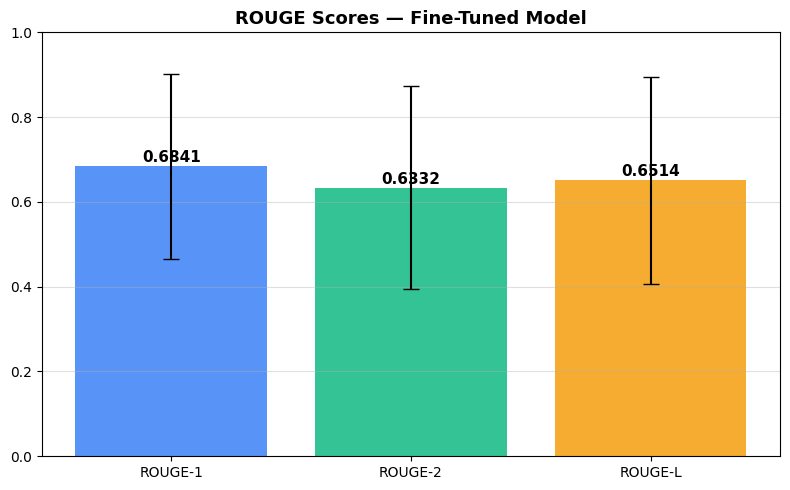

In [17]:
from rouge_score import rouge_scorer
import numpy as np
import matplotlib.pyplot as plt

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
r1, r2, rL = [], [], []

for res in val_results:
    s = scorer.score(res['ground_truth'], res['generated'])
    r1.append(s['rouge1'].fmeasure)
    r2.append(s['rouge2'].fmeasure)
    rL.append(s['rougeL'].fmeasure)

print("="*45)
print("          ROUGE SCORES")
print("="*45)
print(f"  ROUGE-1 : {np.mean(r1):.4f} ± {np.std(r1):.4f}")
print(f"  ROUGE-2 : {np.mean(r2):.4f} ± {np.std(r2):.4f}")
print(f"  ROUGE-L : {np.mean(rL):.4f} ± {np.std(rL):.4f}")
print("="*45)
print(f"\n  Per-sample:")
for i,(a,b,c) in enumerate(zip(r1,r2,rL)):
    print(f"    {i+1}: R1={a:.4f}  R2={b:.4f}  RL={c:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
means   = [np.mean(r1), np.mean(r2), np.mean(rL)]
stds    = [np.std(r1),  np.std(r2),  np.std(rL)]
bars    = ax.bar(metrics, means, yerr=stds, capsize=6,
                 color=['#3b82f6','#10b981','#f59e0b'], alpha=0.85)
for b, m in zip(bars, means):
    ax.text(b.get_x()+b.get_width()/2., b.get_height()+0.01,
            f'{m:.4f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("ROUGE Scores — Fine-Tuned Model",
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rouge.png", dpi=150, bbox_inches='tight')
plt.show()

Testing on 3 training images...
  Train 1: ROUGE-L = 0.7986
  Train 2: ROUGE-L = 0.9822
  ⏳ keepalive #33
  Train 3: ROUGE-L = 0.2441
  Unseen 1: 222 chars generated
  Unseen 2: 2925 chars generated
  Unseen 3: 173 chars generated


/tmp/ipykernel_57/2369732419.py:82: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


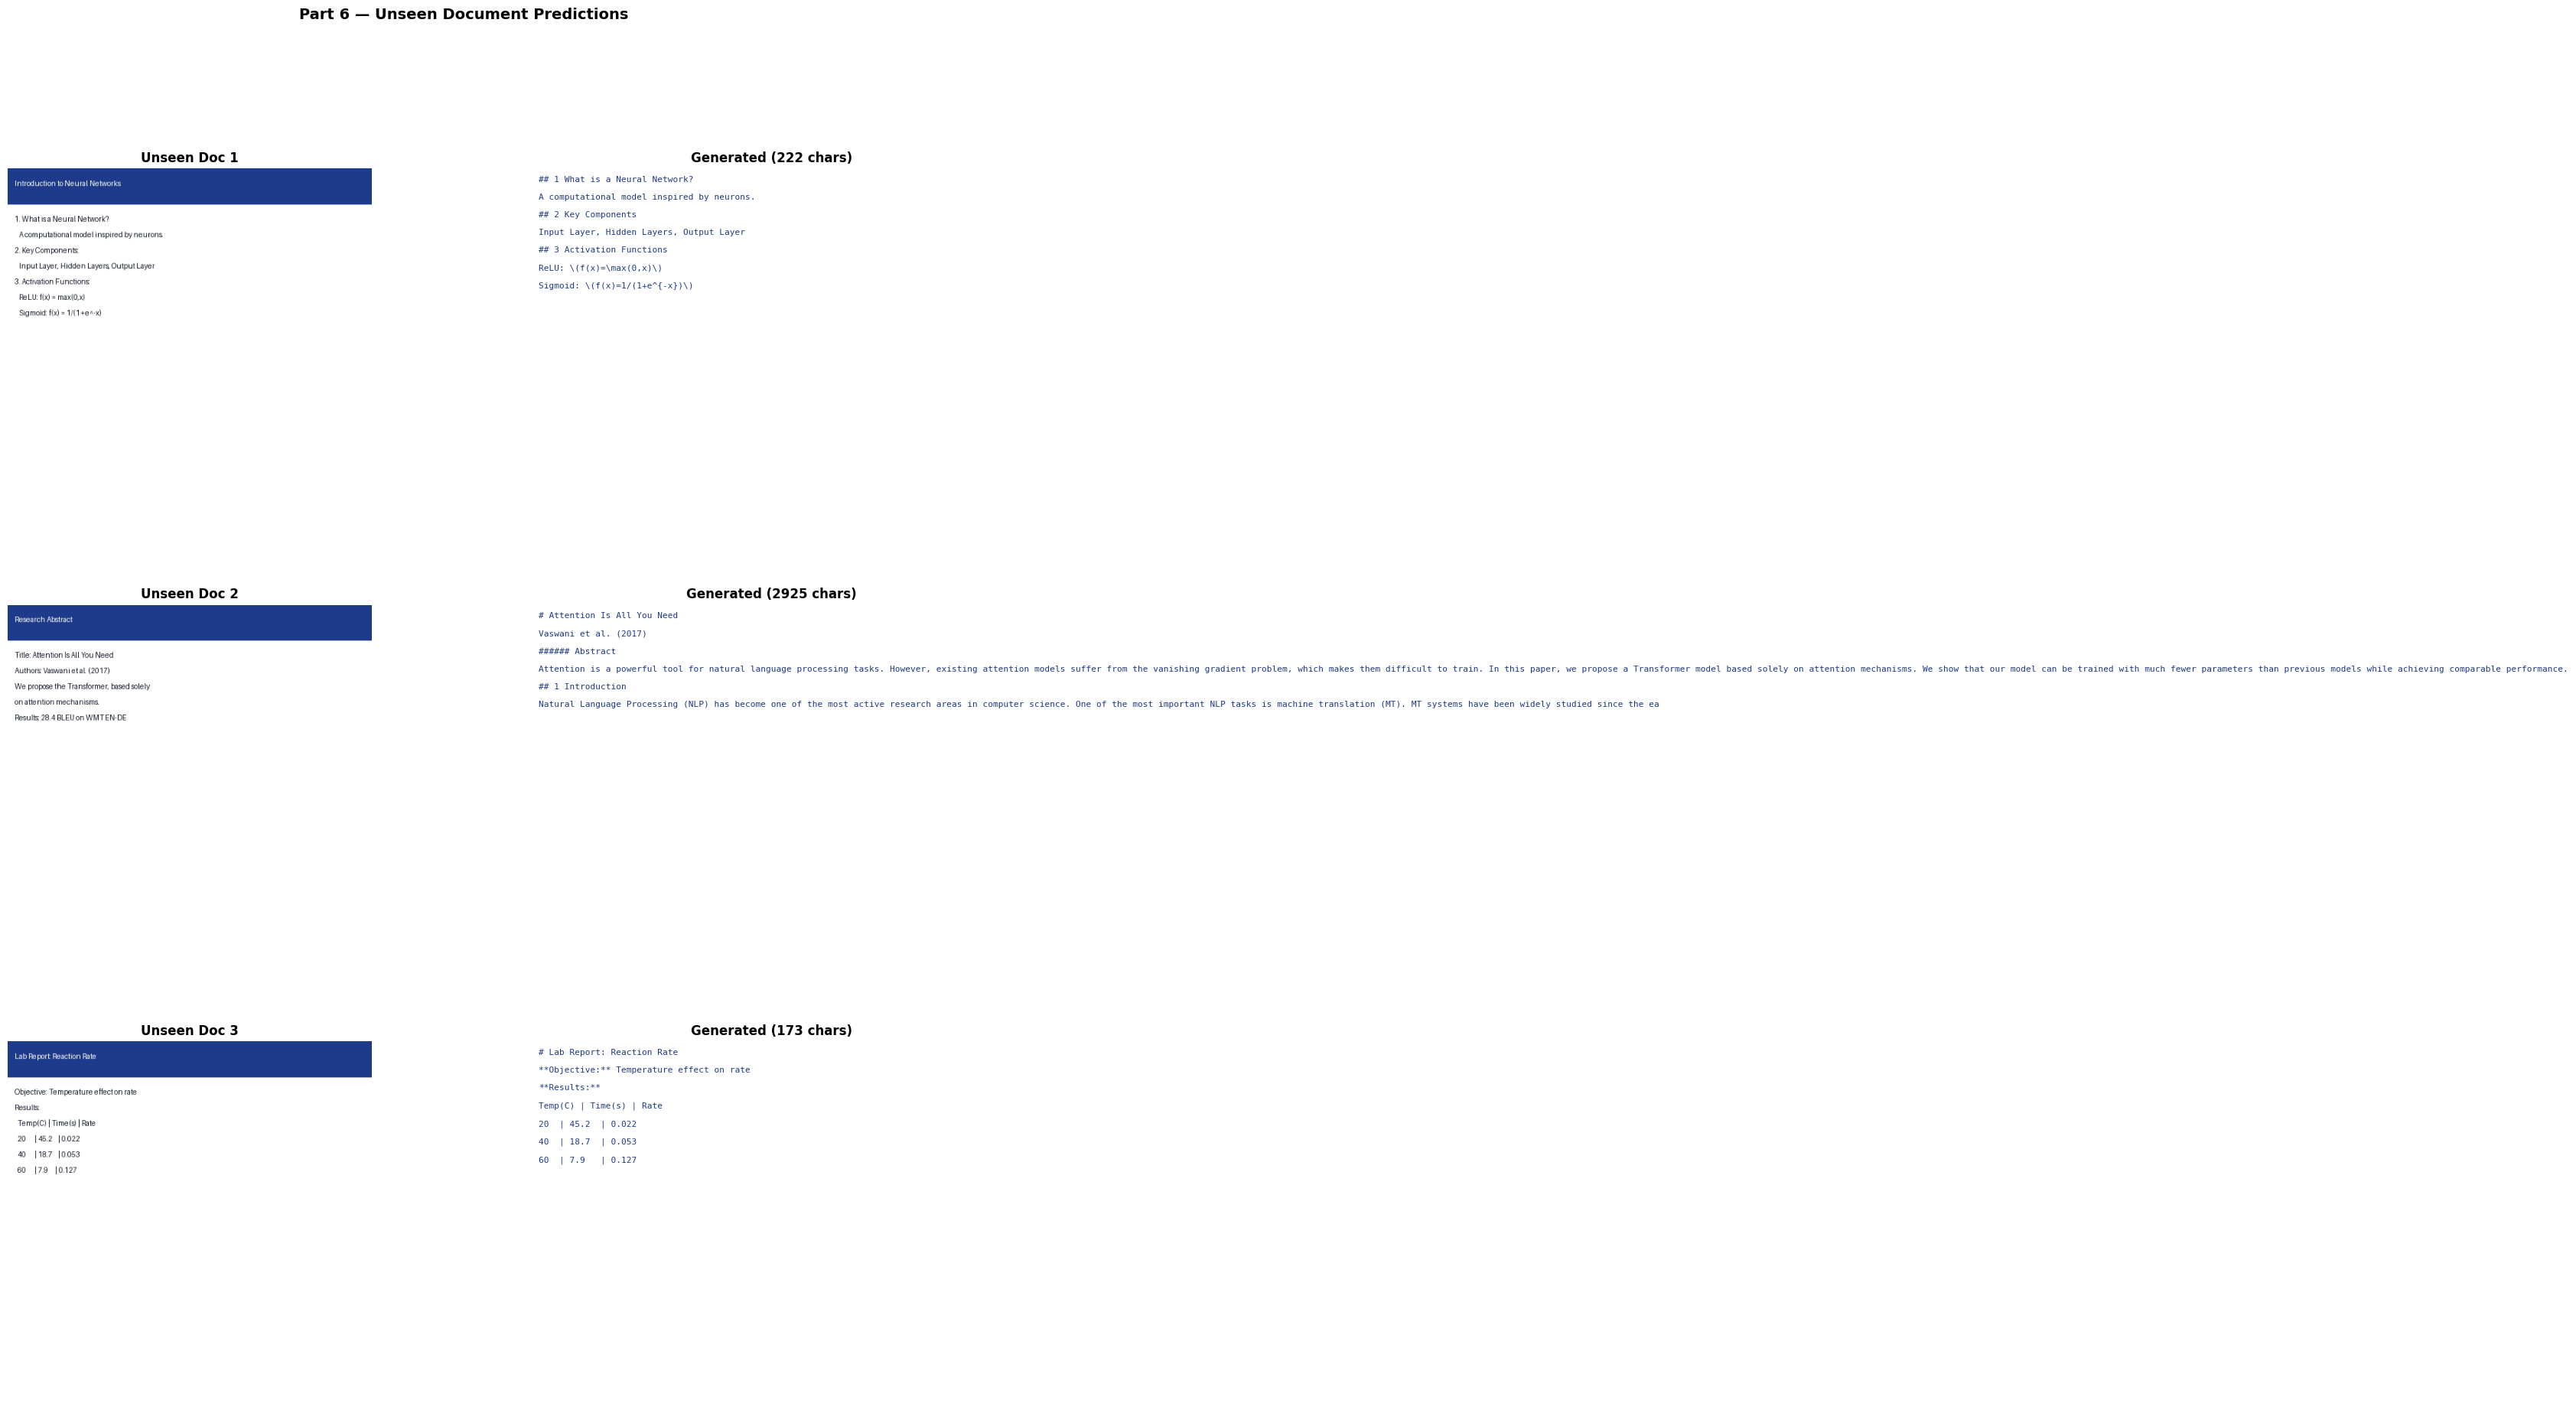

✅ Saved → /kaggle/working/outputs/unseen.png


In [18]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# ── 3 Training images ─────────────────────────────────────────────────
print("Testing on 3 training images...")
train_test = []
for pair in train_dataset.pairs[:3]:
    with open(pair['markdown_path'], 'r',
              encoding='utf-8', errors='replace') as f:
        gt = f.read().strip()
    gen = generate_markdown(ft_model, ft_processor, pair['image_path'])
    s   = scorer.score(gt, gen)
    train_test.append({
        "image_path": pair['image_path'],
        "ground_truth": gt, "generated": gen,
        "rougeL": s['rougeL'].fmeasure
    })
    print(f"  Train {len(train_test)}: ROUGE-L = {s['rougeL'].fmeasure:.4f}")

# ── Create 3 synthetic unseen documents ──────────────────────────────
def make_doc(lines, fname):
    img  = Image.new('RGB', (512, 512), 'white')
    draw = ImageDraw.Draw(img)
    draw.rectangle([0, 0, 512, 50], fill='#1e3a8a')
    draw.text((10, 15), lines[0], fill='white')
    y = 65
    for line in lines[1:]:
        draw.text((10, y), line, fill='#111827')
        y += 22
        if y > 480: break
    path = f"{OUTPUT_DIR}/{fname}"
    img.save(path)
    return path

docs = [
    ["Introduction to Neural Networks",
     "1. What is a Neural Network?",
     "   A computational model inspired by neurons.",
     "2. Key Components:",
     "   Input Layer, Hidden Layers, Output Layer",
     "3. Activation Functions:",
     "   ReLU: f(x) = max(0,x)",
     "   Sigmoid: f(x) = 1/(1+e^-x)"],
    ["Research Abstract",
     "Title: Attention Is All You Need",
     "Authors: Vaswani et al. (2017)",
     "We propose the Transformer, based solely",
     "on attention mechanisms.",
     "Results: 28.4 BLEU on WMT EN-DE"],
    ["Lab Report: Reaction Rate",
     "Objective: Temperature effect on rate",
     "Results:",
     "  Temp(C) | Time(s) | Rate",
     "  20      | 45.2    | 0.022",
     "  40      | 18.7    | 0.053",
     "  60      | 7.9     | 0.127"],
]

unseen_results = []
for i, lines in enumerate(docs):
    path = make_doc(lines, f"unseen_{i+1}.png")
    gen  = generate_markdown(ft_model, ft_processor, path)
    unseen_results.append({"image_path": path, "generated": gen})
    print(f"  Unseen {i+1}: {len(gen)} chars generated")

# ── Visualize unseen ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 21))
fig.suptitle("Part 6 — Unseen Document Predictions",
             fontsize=14, fontweight='bold')
for i, res in enumerate(unseen_results):
    img = Image.open(res['image_path'])
    axes[i][0].imshow(img)
    axes[i][0].set_title(f"Unseen Doc {i+1}", fontweight='bold')
    axes[i][0].axis('off')
    axes[i][1].set_facecolor('#eff6ff')
    axes[i][1].text(0.02, 0.98, res['generated'][:700],
                    transform=axes[i][1].transAxes, fontsize=8,
                    va='top', fontfamily='monospace', color='#1e3a8a')
    axes[i][1].set_title(f"Generated ({len(res['generated'])} chars)",
                          fontweight='bold')
    axes[i][1].axis('off')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/unseen.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {OUTPUT_DIR}/unseen.png")

In [19]:
print("="*100)
print(f"  {'ACTUAL vs PREDICTED COMPARISON':^96}")
print("="*100)
for i, res in enumerate(val_results[:5]):
    gt_l  = res['ground_truth'].split('\n')[:8]
    gen_l = res['generated'].split('\n')[:8]
    mx    = max(len(gt_l), len(gen_l))
    gt_l  += [''] * (mx - len(gt_l))
    gen_l += [''] * (mx - len(gen_l))
    s = scorer.score(res['ground_truth'], res['generated'])
    print(f"\n  Sample {i+1} | "
          f"R1:{s['rouge1'].fmeasure:.3f}  "
          f"R2:{s['rouge2'].fmeasure:.3f}  "
          f"RL:{s['rougeL'].fmeasure:.3f}")
    print(f"  {'GROUND TRUTH':48s}  {'GENERATED':48s}")
    print(f"  {'-'*96}")
    for g, p in zip(gt_l, gen_l):
        print(f"  {g[:46]:48s}  {p[:46]:48s}")

                                   ACTUAL vs PREDICTED COMPARISON                                 

  Sample 1 | R1:0.568  R2:0.455  RL:0.498
  GROUND TRUTH                                      GENERATED                                       
  ------------------------------------------------------------------------------------------------
  The mass scale governing the variation of \(F(    The mass scale governing the variation of \(F(  
                                                                                                    
  All other contributions to the EDFF are formal    All other contributions to the EDFF are formal  
                                                                                                    
  Lstr/em(1)=12mN{N-((vD)2-D2)N+gAfp[iN-(vD)SDN+    \[{\cal L}_{\rm{pert}}^{\rm{(1)}}= {2\over 3m_  
                                                                                                    
  These are nucleon recoil corrections to the st    

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Loading base model for zero-shot...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Sample 1: ZS=0.4957  FT=0.4976  Δ=+0.0018
Sample 2: ZS=0.8568  FT=0.8645  Δ=+0.0077


/tmp/ipykernel_57/3588896796.py:48: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


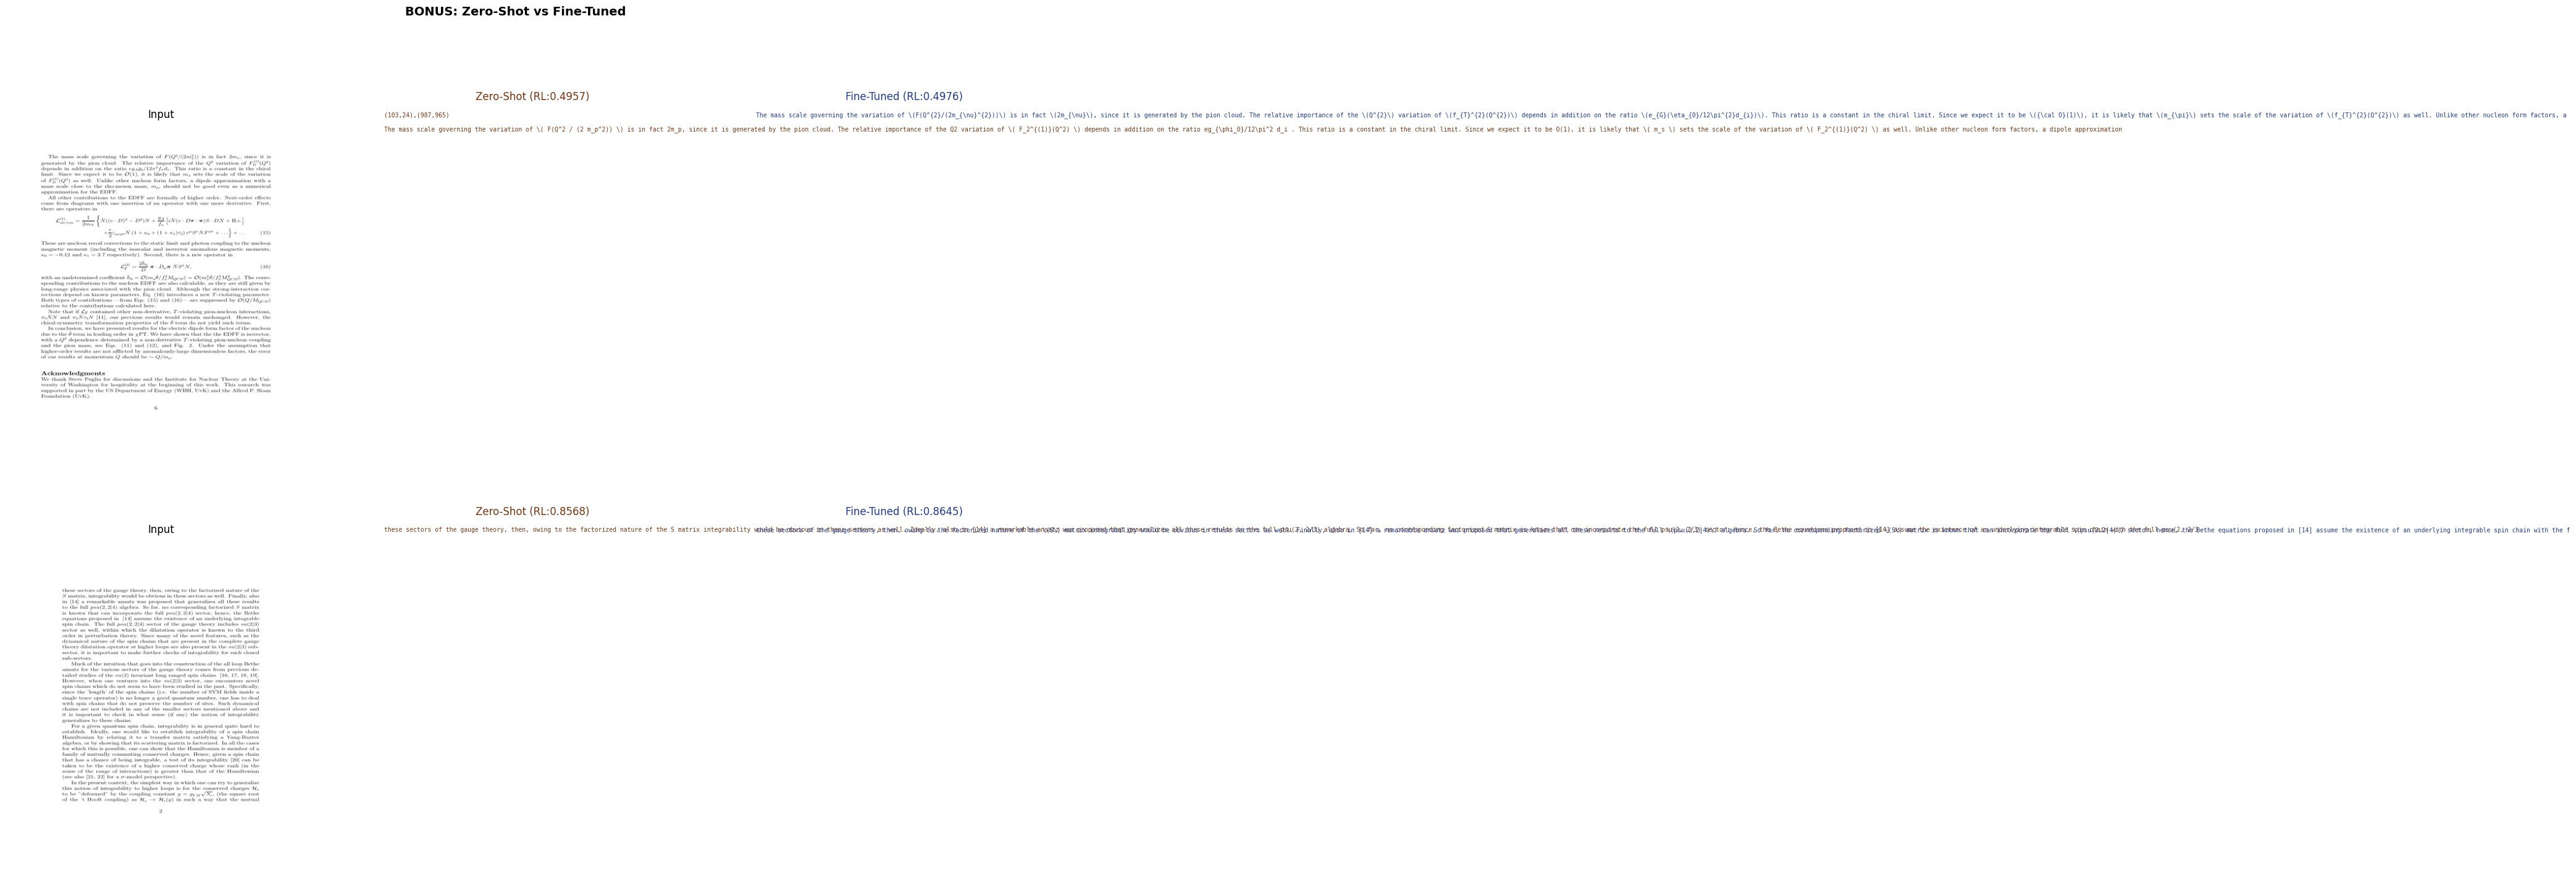

✅ Comparison saved


In [20]:
import peft.import_utils as pu
pu.is_bnb_available = lambda: False
pu.is_bnb_4bit_available = lambda: False

print("Loading base model for zero-shot...")
zs_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, device_map="auto",
    torch_dtype=torch.float16, trust_remote_code=True)
zs_model.eval()

fig, axes = plt.subplots(2, 3, figsize=(22, 16))
fig.suptitle("BONUS: Zero-Shot vs Fine-Tuned",
             fontsize=14, fontweight='bold')

for i, pair in enumerate(val_dataset.pairs[:2]):
    with open(pair['markdown_path'], 'r',
              encoding='utf-8', errors='replace') as f:
        gt = f.read().strip()
    zs  = generate_markdown(zs_model,  ft_processor, pair['image_path'])
    ftu = generate_markdown(ft_model,  ft_processor, pair['image_path'])
    zs_rl = scorer.score(gt, zs)['rougeL'].fmeasure
    ft_rl = scorer.score(gt, ftu)['rougeL'].fmeasure
    print(f"Sample {i+1}: ZS={zs_rl:.4f}  FT={ft_rl:.4f}  "
          f"Δ={ft_rl-zs_rl:+.4f}")

    img = Image.open(pair['image_path']).convert("RGB")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

    axes[i][0].imshow(img)
    axes[i][0].set_title("Input"); axes[i][0].axis('off')

    axes[i][1].set_facecolor('#fef9c3')
    axes[i][1].text(0.02, 0.98, zs[:500],
                    transform=axes[i][1].transAxes,
                    fontsize=7, va='top',
                    fontfamily='monospace', color='#78350f')
    axes[i][1].set_title(f"Zero-Shot (RL:{zs_rl:.4f})",
                          color='#78350f'); axes[i][1].axis('off')

    axes[i][2].set_facecolor('#eff6ff')
    axes[i][2].text(0.02, 0.98, ftu[:500],
                    transform=axes[i][2].transAxes,
                    fontsize=7, va='top',
                    fontfamily='monospace', color='#1e3a8a')
    axes[i][2].set_title(f"Fine-Tuned (RL:{ft_rl:.4f})",
                          color='#1e3a8a'); axes[i][2].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/zeroshot_vs_finetuned.png",
            dpi=120, bbox_inches='tight')
plt.show()
del zs_model; torch.cuda.empty_cache()
print("✅ Comparison saved")

In [21]:
import os, shutil, zipfile
from pathlib import Path

# ── 1. Merge LoRA adapter into base model (optional but recommended) ──
# Merged model = single standalone file, no need for PEFT at inference
print("⚙️  Merging LoRA adapter into base model...")
merged_model = ft_model.merge_and_unload()
print("✅ LoRA merged into base model")

# ── 2. Save merged model ──────────────────────────────────────────────
MERGED_DIR = "/kaggle/working/merged_model"
os.makedirs(MERGED_DIR, exist_ok=True)

print(f"⚙️  Saving merged model to {MERGED_DIR}...")
merged_model.save_pretrained(MERGED_DIR, safe_serialization=True)
ft_processor.save_pretrained(MERGED_DIR)
print("✅ Merged model saved")

# ── 3. Also save just the adapter (much smaller — 50-100MB) ──────────
ADAPTER_EXPORT = "/kaggle/working/lora_adapter_only"
os.makedirs(ADAPTER_EXPORT, exist_ok=True)
ft_model.save_pretrained(ADAPTER_EXPORT)
ft_processor.save_pretrained(ADAPTER_EXPORT)
print(f"✅ LoRA adapter saved to {ADAPTER_EXPORT}")

# ── 4. Zip both for download ──────────────────────────────────────────
print("\n⚙️  Zipping files for download...")

def zip_folder(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for file in Path(folder_path).rglob('*'):
            if file.is_file():
                zf.write(file, file.relative_to(folder_path))
    size = os.path.getsize(zip_path) / 1e6
    print(f"   ✅ {os.path.basename(zip_path):40s} {size:.1f} MB")
    return zip_path

# Zip adapter only (small, fast download ~50-100MB)
adapter_zip = zip_folder(ADAPTER_EXPORT,
                          "/kaggle/working/lora_adapter_only.zip")

# Zip merged model (larger ~4-5GB — takes a few minutes)
merged_zip  = zip_folder(MERGED_DIR,
                          "/kaggle/working/merged_model.zip")

# ── 5. Show all downloadable files ───────────────────────────────────
print("\n" + "="*60)
print("         FILES READY FOR DOWNLOAD")
print("="*60)

download_files = [
    "/kaggle/working/lora_adapter_only.zip",
    "/kaggle/working/merged_model.zip",
    f"{OUTPUT_DIR}/loss_curves.png",
    f"{OUTPUT_DIR}/predictions.png",
    f"{OUTPUT_DIR}/rouge.png",
    f"{OUTPUT_DIR}/unseen.png",
    f"{OUTPUT_DIR}/epoch_comparison.png",
    f"{OUTPUT_DIR}/zeroshot_vs_finetuned.png",
    f"{OUTPUT_DIR}/dataset_samples.png",
]

for fpath in download_files:
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1e6
        print(f"  ✅ {os.path.basename(fpath):45s} {size:.1f} MB")
    else:
        print(f"  ⚠️  {os.path.basename(fpath):45s} NOT FOUND")

print("="*60)
print("\n📥 HOW TO DOWNLOAD:")
print("   1. Look at the Output panel on the right side")
print("   2. Find 'lora_adapter_only.zip' → click ⋮ → Download")
print("   3. Find 'merged_model.zip'      → click ⋮ → Download")
print("   4. Or: Save Version → then download from notebook output")
print("\n💡 RECOMMENDATION:")
print("   Download 'lora_adapter_only.zip' (~100MB) for sharing.")
print("   Download 'merged_model.zip' (~4GB) only if you need")
print("   a standalone model without PEFT installed.")
print("\n☁️  ALSO PUSHED TO KAGGLE DATASET:")

# Push model to your Kaggle dataset too
try:
    import json, subprocess
    meta = {
        "title": "qwen2vl-checkpoints",
        "id":    CHECKPOINT_DATASET,
        "licenses": [{"name": "CC0-1.0"}]
    }
    with open(f"{CKPT_DIR}/dataset-metadata.json", "w") as f:
        json.dump(meta, f)

    # Copy adapter zip to checkpoints dir for push
    shutil.copy(adapter_zip, CKPT_DIR)

    r = subprocess.run(
        ["kaggle", "datasets", "version",
         "-p", CKPT_DIR, "-m", "final_adapter",
         "--dir-mode", "zip"],
        capture_output=True, text=True, timeout=300)
    if r.returncode == 0:
        print(f"   ✅ Pushed to kaggle.com/datasets/{CHECKPOINT_DATASET}")
    else:
        print(f"   ⚠️  Push failed: {r.stderr[:150]}")
except Exception as e:
    print(f"   ⚠️  Push error: {e}")

print("\n✅ All done!")

⚙️  Merging LoRA adapter into base model...
✅ LoRA merged into base model
⚙️  Saving merged model to /kaggle/working/merged_model...
✅ Merged model saved
✅ LoRA adapter saved to /kaggle/working/lora_adapter_only

⚙️  Zipping files for download...
   ✅ lora_adapter_only.zip                    3.9 MB
  ⏳ keepalive #34
  ⏳ keepalive #35
   ✅ merged_model.zip                         3806.6 MB

         FILES READY FOR DOWNLOAD
  ✅ lora_adapter_only.zip                         3.9 MB
  ✅ merged_model.zip                              3806.6 MB
  ✅ loss_curves.png                               0.1 MB
  ✅ predictions.png                               0.9 MB
  ✅ rouge.png                                     0.0 MB
  ✅ unseen.png                                    0.2 MB
  ⚠️  epoch_comparison.png                          NOT FOUND
  ✅ zeroshot_vs_finetuned.png                     0.6 MB
  ✅ dataset_samples.png                           0.6 MB

📥 HOW TO DOWNLOAD:
   1. Look at the Output panel o